In [ ]:
# now that we have a pretrained model
# we will evaluate its pretraining performance

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

In [62]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from src.evals import evaluate_model, generate_and_print_sample
from src.dataloaderv1 import create_dataloaderV1
from src.gpt import GPT8TModel

from src.checkpointing import load_checkpoint

from src.utils import *
from src.config import config

from pathlib import Path
import tiktoken

torch.manual_seed(42)

In [63]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
path_to_checkpoint = Path.cwd().parent / "models" / "V0" / "checkpoints" / "latest_model.pt"
path_to_best_checkpoint = Path.cwd().parent / "models" / "V0" / "checkpoints" / "best_model.pt"
tokenizer = tiktoken.get_encoding('gpt2')

model = GPT8TModel(
    emb_dim = config['emb_dim'],
    vocab_size = config['vocab_size'],
    context_length = config['context_length'],
    n_layers = config['n_layers'],
    n_heads = config['n_heads'],
    emb_dropout = config['emb_dropout'],
    mha_dropout = config['mha_dropout'],
    dropout = config['dropout'],
    expanding_factor = 6
)
model.to(device)

model, _, _, _, tokens_seen, train_losses, _, val_losses, _, all_tokens_seen, best_val_loss = load_checkpoint(path_to_checkpoint, model, None, device)

In [64]:
print(model)

GPT8TModel(
  (tok_emb): Embedding(50257, 512)
  (pos_emb): Embedding(256, 512)
  (embeds_dropout): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (multiheadattention): MultiHeadAttention(
        (dropout): Dropout(p=0.1, inplace=False)
        (Wq): Linear(in_features=512, out_features=512, bias=False)
        (Wk): Linear(in_features=512, out_features=512, bias=False)
        (Wv): Linear(in_features=512, out_features=512, bias=False)
        (output_proj): Linear(in_features=512, out_features=512, bias=True)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (norm2): LayerNorm()
      (fnn): FeedForwardNetwork(
        (layers): Sequential(
          (0): Linear(in_features=512, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=512, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (multiheadattention): 

In [65]:
# now lets just use the model to make a simple prediction just to see using our own eyes how good the model is
# without any evaluations

# multiple text examples
sample_texts = ["I was running down the street when", "The little girl"]

for text in sample_texts:
    generate_and_print_sample(model, tokenizer, device, text, max_new_tokens=50, context_length=config['context_length'])

Generated text: I was running down the street when I was going to go to the park. I was going to the park and I was going to the park. I was going to the park and I was going to the park. I was going to the park and I was going to the park
Generated text: The little girl was so excited! She ran to the park and ran to the park.

When she got to the park, she saw a big tree with lots of leaves. She ran to the tree and ran to the tree. She saw a big tree


In [66]:
# well as we can see the outputs are kinda not that bad for a 60Mill param model
# + we had lots of limitations that brought the model back in terms of training that we will cover later along the way
# for now lets plot the train losses and val losses

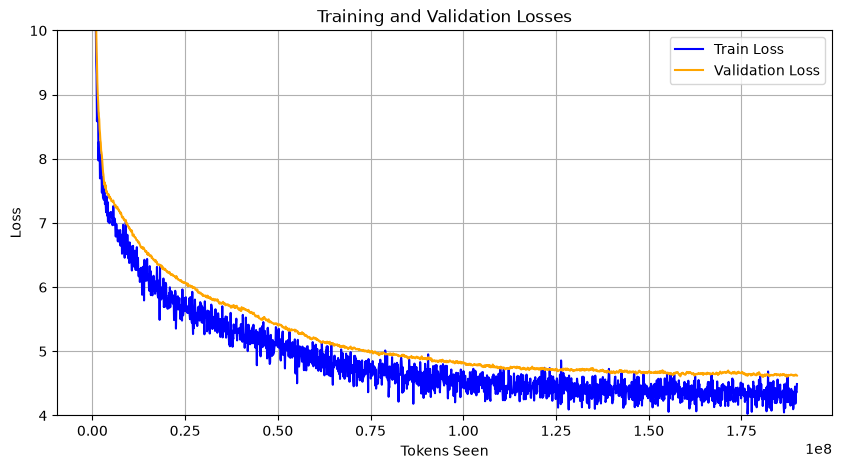

In [67]:
# we now plot the train and val losses to see how the model performed during training

plt.figure(figsize=(10, 5))
plt.plot(all_tokens_seen, train_losses, label='Train Loss', color='blue')
plt.plot(all_tokens_seen, val_losses, label='Validation Loss', color='orange')
plt.xlabel('Tokens Seen')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')

plt.ylim(4, 10)

plt.legend()
plt.grid()
plt.show()

In [68]:
# well as we can see at first both the val and train losses were descending together
# then val loss started to to some kind of plateau while train loss kept descending
# this is a sign of overfitting, which is expected since we have a small dataset and a large model
# and we trained the model on a small dataset for a long time, which is not ideal

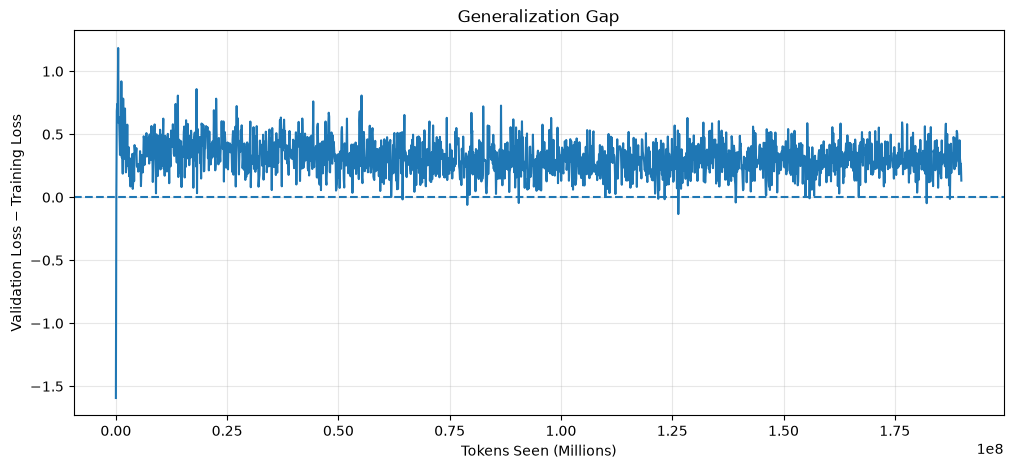

In [69]:
loss_gap = [
    val - train
    for train, val in zip(train_losses, val_losses)
]

plt.figure(figsize=(12, 5))

plt.plot(
    all_tokens_seen,
    loss_gap
)

plt.axhline(0, linestyle="--")

plt.xlabel("Tokens Seen (Millions)")
plt.ylabel("Validation Loss − Training Loss")
plt.title("Generalization Gap")
plt.grid(alpha=0.3)
plt.show()

In [70]:
# we can now compare it with 2 other models
# the best_model which is just an instance of the model with the best validation loss during training
# and an untrained model

In [71]:
# creating the untrained model
untrained_model = GPT8TModel(
    emb_dim = config['emb_dim'],
    vocab_size = config['vocab_size'],
    context_length = config['context_length'],
    n_layers = config['n_layers'],
    n_heads = config['n_heads'],
    emb_dropout = config['emb_dropout'],
    mha_dropout = config['mha_dropout'],
    dropout = config['dropout'],
    expanding_factor = 6
)
untrained_model.to(device)

lowest_val_loss_model = GPT8TModel(
    emb_dim = config['emb_dim'],
    vocab_size = config['vocab_size'],
    context_length = config['context_length'],
    n_layers = config['n_layers'],
    n_heads = config['n_heads'],
    emb_dropout = config['emb_dropout'],
    mha_dropout = config['mha_dropout'],
    dropout = config['dropout'],
    expanding_factor = 6
)
lowest_val_loss_model.to(device)

lowest_val_loss_model, _, _, _, tokens_seen_best, train_losses_best, _, val_losses_best\
, _, all_tokens_seen_best, best_val_loss_best = load_checkpoint(path_to_best_checkpoint, lowest_val_loss_model, None, device)

In [72]:
generate_and_print_sample(model, tokenizer, device, "The little girl", max_new_tokens=50, context_length=config['context_length'])

Generated text: The little girl was so excited! She ran to the park and ran to the park.

When she got to the park, she saw a big tree with lots of leaves. She ran to the tree and ran to the tree. She saw a big tree


In [73]:
generate_and_print_sample(untrained_model, tokenizer, device, "The little girl", max_new_tokens=50, context_length=config['context_length'])

Generated text: The little girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl girl


In [74]:
generate_and_print_sample(lowest_val_loss_model, tokenizer, device, "The little girl", max_new_tokens=50, context_length=config['context_length'])

Generated text: The little girl was very excited. She wanted to play with the ball, but she couldn't find it. She asked her mom if she could play with it. Her mom said yes and said yes.

The little girl was so excited. She took the


In [75]:
# well as we can see the model as a model itself is not that bad
# however we can see that the outputs themselves kinda feel dumb and repetitive
# so lets address all these problems one at a time

# first of all we will address the overfitting problem
# as we can see to some extent the model probably did overfit to the training data it is not that apparent 
# the problem is most definitely the high number of epochs on a small dataset, which is not ideal

# second of all we will address the problem of the model being kinda limited in its predictions and outputs 
# the problem here is most defintely the small dataset size and because we kind of splitted the dataset aggressively
# we ended up in having a small portion of the already small dataset being used for training
# moreover the itself is only a 60Mill param model
# being 60 Mill param model trained on only around 66Mill tokens is not ideal
# and according to Chinchilla scaling laws, the model is undertrained and underfitted to the dataset
# because the law states that u should train a model on 20x the number of tokens as the number of parameters in the model

# third of all the reason of it being repetitive is because we still havent applied any kind of sampling techniques to the model outputs
# this is because we are using greedy decoding, which is not ideal for text generation tasks
# however we will address this problem later because id prefer training a better model for now

# fourthly the model doesnt stop as u can see it prefers repeating the same word over and over again
# this might be caused because the data itself is not preprocessed to have the EOS token at the end of each text sample


# finally even tho the loss is somewhat not that bad it is sitting at around 4.6 for the validation loss
# despite this the model is still not that good
# this is caused by a mix of the problems we mentioned above
# plus the data being non diverse, noisy and small, which is not ideal for training a model on it